# TP1 — G4 — Baseline clássico para o SIIM-FISABIO-RSNA COVID-19 Detection (2021)

Este notebook reproduz **todas** as tabelas e figuras do artigo.

**Configuração no Kaggle (painel direito):**
1. *Add Input* → aba *Competitions* → `SIIM-FISABIO-RSNA COVID-19 Detection` (é preciso ter aceitado as regras da competição).
2. *Settings* → *Internet*: **On** (exige conta verificada por telefone).
3. *Accelerator*: **None** (CPU; o método não usa GPU).

**Execução recomendada:**
- Teste rápido: defina `SAMPLE_FRAC = 0.1` e rode célula a célula (~20–30 min).
- Execução final: volte para `SAMPLE_FRAC = 1.0` e use *Save Version → Save & Run All (Commit)*. Roda em segundo plano (limite de 12 h), e os arquivos de `/kaggle/working` ficam disponíveis na aba *Output*.

In [1]:
REPO_URL = "https://github.com/FelipeFreires-Costa/COVID-19-AI-Detection-AP1.git"
SAMPLE_FRAC = 1.0  # 0.1 para teste rapido

import glob, os
os.chdir("/kaggle/working")
if not os.path.exists("repo"):
    os.system(f"git clone -q {REPO_URL} repo")
os.chdir("/kaggle/working/repo")

csv = glob.glob("/kaggle/input/**/train_study_level.csv", recursive=True)
assert csv, "Adicione a competicao siim-covid19-detection como input do notebook"
os.environ["SIIM_DATA_DIR"] = os.path.dirname(csv[0])
os.environ["TP1_WORK_DIR"] = "/kaggle/temp/work" if os.path.isdir("/kaggle/temp") else "/kaggle/working/work"
os.environ["TP1_SAMPLE_FRAC"] = str(SAMPLE_FRAC)
RES = "results" if SAMPLE_FRAC >= 1 else f"results_frac{SAMPLE_FRAC:g}"
print(os.environ["SIIM_DATA_DIR"], RES)

/kaggle/input/competitions/siim-covid19-detection results


In [2]:
# Decodificadores de DICOM comprimido (JPEG/JPEG-LS/JPEG2000).
!pip install -q pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg python-gdcm
!mkdir -p $RES && pip freeze > $RES/environment_kaggle.txt
!python -c "import sklearn, skimage, pydicom, lightgbm, cv2; print(sklearn.__version__, skimage.__version__, pydicom.__version__, lightgbm.__version__, cv2.__version__)"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 71.2 MB/s eta 0:00:00
1.6.1 0.25.2 3.0.2 4.6.0 4.13.0


## 1. Dados: DICOM → PNG 512, metadados, amostragem e partição por paciente (Felipe)

In [3]:
!python src/prepare_data.py

Estudos no treino oficial: 6054 | imagens: 6334
Amostra (frac=1.0): 6054 estudos, 6334 imagens
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    3.8s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   10.8s
/usr/local/lib/python3.12/dist-packages/pydicom/pixels/decoders/base.py:814: UserWarning: The pixel data is 13262360 bytes long, which indicates it contains 216296 bytes of excess padding to be removed
  warn_and_log(
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:   21.3s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:   37.2s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   58.3s
[Parallel(n_jobs=4)]: Done 640 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done 874 tasks      | elapsed:  2.2min
[Parallel(n_jobs=4)]: Done 1144 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 1450 tasks      | elapsed:  3.6min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  4.3min

## 2. Análise exploratória (Felipe)

Estudos: 6054
Imagens: 6334
Pacientes: 3261
Estudos com >1 imagem: 232
Estudos por paciente (max): 25
Pacientes com >1 estudo: 1200

Classes (estudos):
classe
Típico           2855
Negativo         1676
Indeterminado    1049
Atípico           474

Classes (%):
classe
Típico           47.2
Negativo         27.7
Indeterminado    17.3
Atípico           7.8

Particao x classe:
split           dev  test
classe                   
Atípico         382    92
Indeterminado   848   201
Negativo       1322   354
Típico         2228   627

Modalidade:
Modality
DX    3242
CR    3092

PhotometricInterpretation:
PhotometricInterpretation
MONOCHROME2    4633
MONOCHROME1    1701

BitsStored:
BitsStored
12.0    4311
15.0    1240
8.0      401
14.0     210
16.0     166
10.0       3
13.0       3

Fabricantes (top 10):
Manufacturer
NaN    6334

PixelSpacing (mm) mediana: 0.139 | faltante: 0.0%
Resolucao original mediana: 2544 x 3028

Caixas de opacidade por imagem (media por classe):
classe
Atípico          

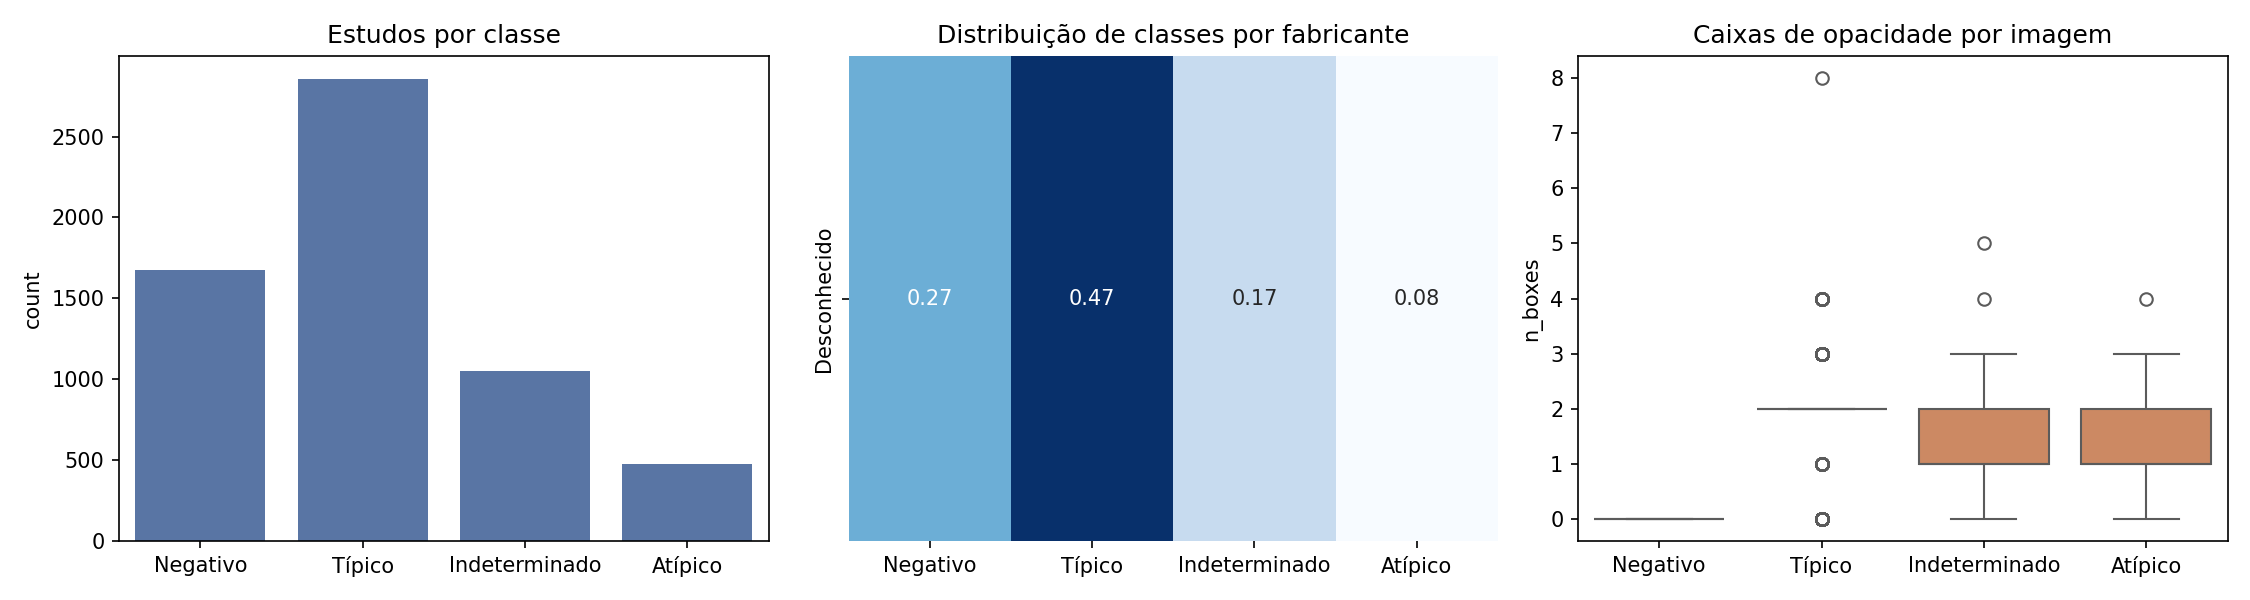

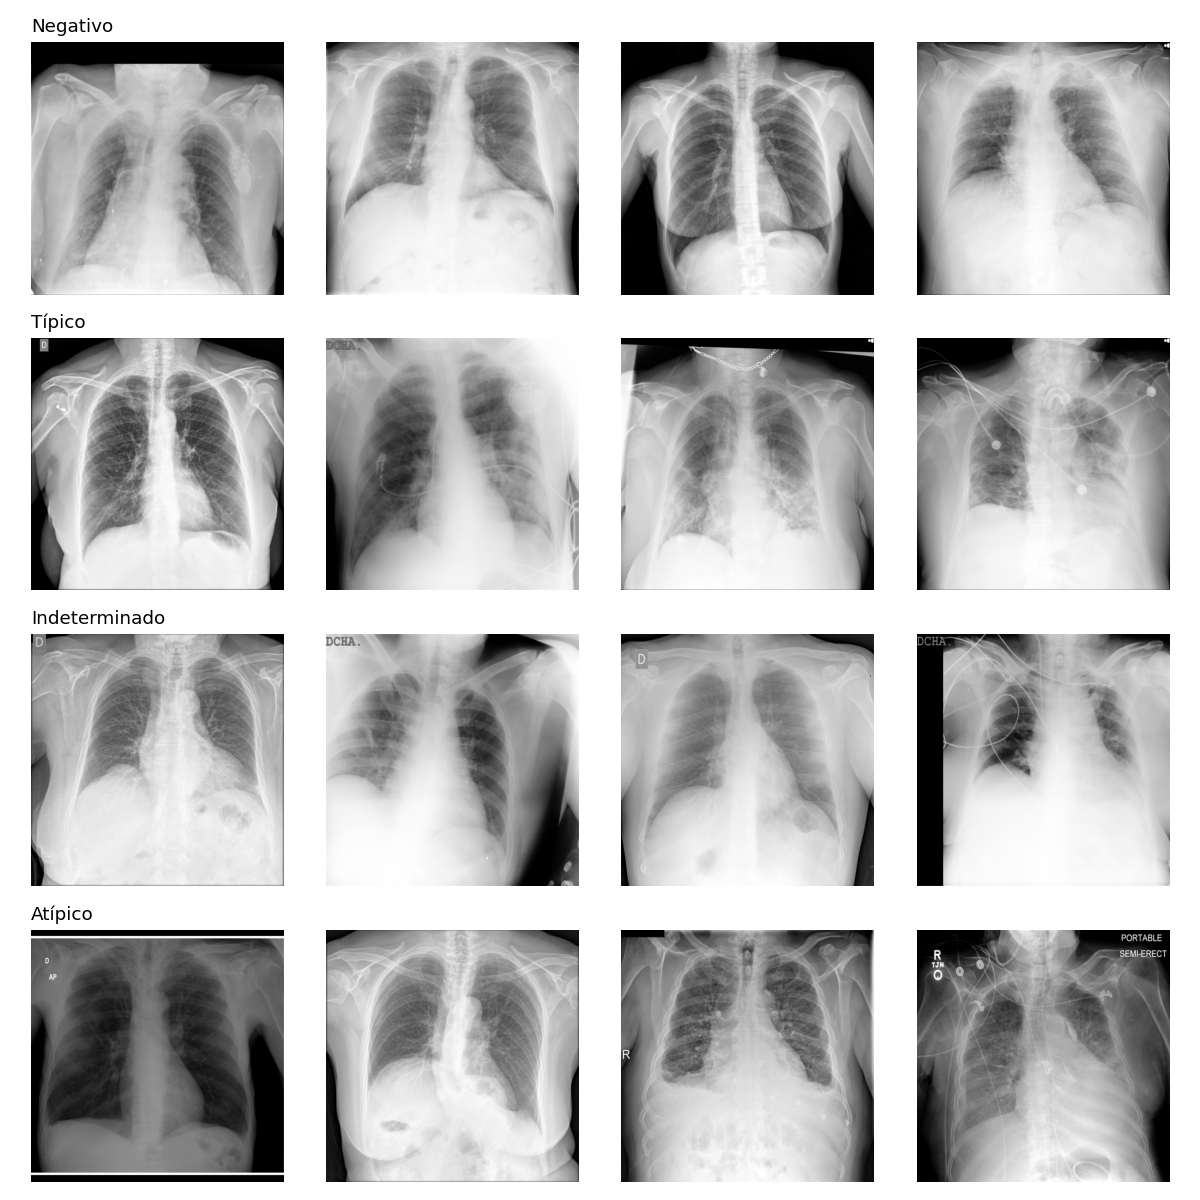

In [4]:
!python src/eda.py
from IPython.display import Image, display
display(Image(f"{RES}/figures/eda_overview.png"))
display(Image(f"{RES}/figures/eda_examples.png", width=700))

## 3. Pré-processamento e extração de características (Eduardo)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 168 tasks      | elapsed:   50.7s
[Parallel(n_jobs=4)]: Done 1032 tasks      | elapsed:  4.2min
[Parallel(n_jobs=4)]: Done 2472 tasks      | elapsed: 10.2min
[Parallel(n_jobs=4)]: Done 4488 tasks      | elapsed: 18.2min
[Parallel(n_jobs=4)]: Done 6330 tasks      | elapsed: 25.3min
[Parallel(n_jobs=4)]: Done 6334 out of 6334 | elapsed: 25.3min finished
6334 imagens, 1924 colunas, 1531s
Estudos: 6054 | fallback de mascara: 9.2%


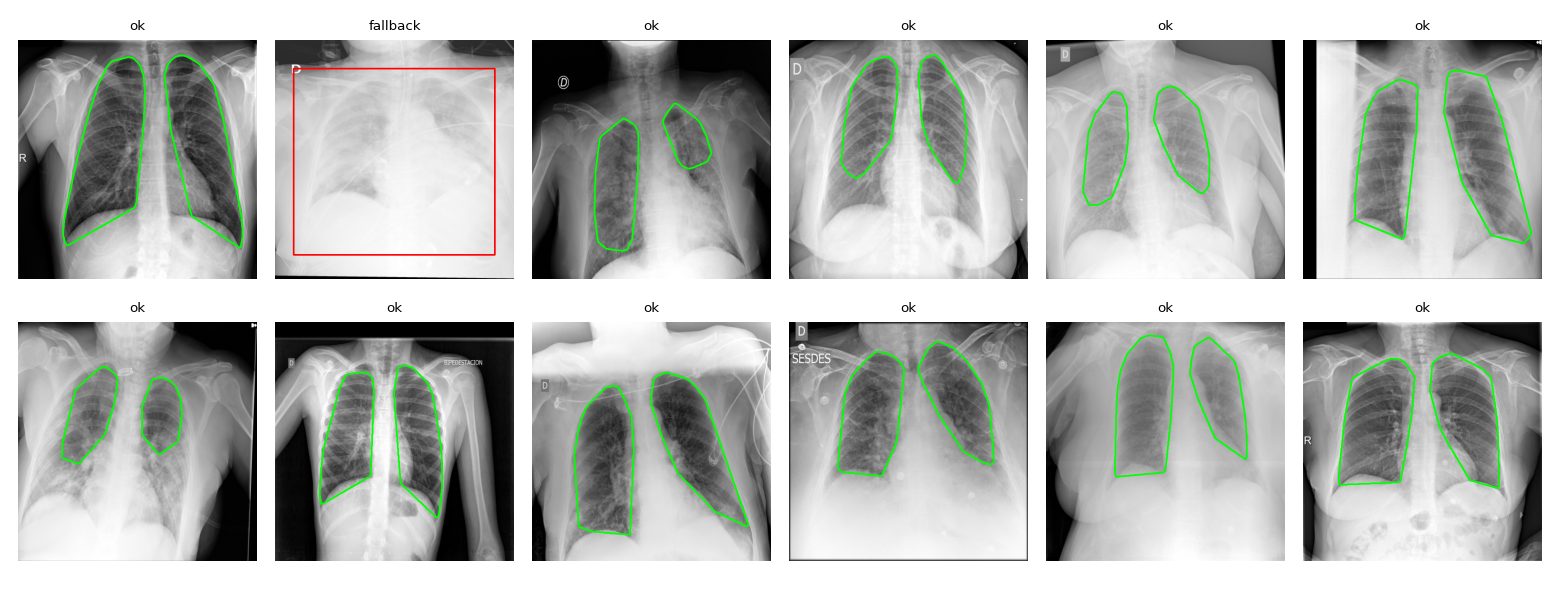

In [5]:
!python src/extract_features.py --tag default --clahe 1 --mask 1
!python src/make_figures.py --only masks
display(Image(f"{RES}/figures/fig_masks.png"))

## 4. Grade descritor × modelo com CV aninhada + avaliação no hold-out (Pedro)

In [6]:
!python src/run_experiments.py --tag default
import pandas as pd
s = pd.read_csv(f"{RES}/tables/cv_summary.csv")
s[["featureset", "model", "auc_macro_mean", "auc_macro_std", "bal_acc_mean", "f1_macro_mean", "bin_auc_mean"]].sort_values("auc_macro_mean", ascending=False)

Estudos: 6054 (dev=4780, teste=1274)
   int |    dummy | AUC 0.500 +- 0.000 | BAcc 0.250 | 0s
   int |   logreg | AUC 0.616 +- 0.011 | BAcc 0.345 | 9s
   int |  svm_rbf | AUC 0.623 +- 0.012 | BAcc 0.334 | 135s
   int |       rf | AUC 0.608 +- 0.010 | BAcc 0.337 | 173s
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with fe

,featureset,model,auc_macro_mean,auc_macro_std,bal_acc_mean,f1_macro_mean,bin_auc_mean
4,all,svm_rbf,0.709882,0.014408,0.395387,0.349259,0.833875
16,hog,svm_rbf,0.701721,0.015788,0.390537,0.342401,0.823827
8,gabor,svm_rbf,0.690441,0.013253,0.382884,0.330859,0.820708
1,all,lgbm,0.689048,0.007771,0.396613,0.372031,0.818627
2,all,logreg,0.688437,0.019168,0.426398,0.408027,0.810924
24,lbp,svm_rbf,0.684699,0.019517,0.377030,0.324412,0.797141
3,all,rf,0.682669,0.015260,0.368242,0.323043,0.797408
13,hog,lgbm,0.679935,0.013281,0.382852,0.353123,0.800886
14,hog,logreg,0.677446,0.016836,0.407390,0.392913,0.792772
5,gabor,lgbm,0.676071,0.008599,0.396083,0.385959,0.812433


## 5. Ablações: pré-processamento (Eduardo) e desbalanceamento (Pedro)

In [7]:
!python src/extract_features.py --tag raw_full --clahe 0 --mask 0
!python src/extract_features.py --tag clahe_full --clahe 1 --mask 0
!python src/extract_features.py --tag raw_mask --clahe 0 --mask 1
!python src/ablation.py --part all
display(pd.read_csv(f"{RES}/tables/ablation_prep.csv"))
display(pd.read_csv(f"{RES}/tables/ablation_imb.csv"))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 168 tasks      | elapsed:   39.1s
[Parallel(n_jobs=4)]: Done 1032 tasks      | elapsed:  3.2min
[Parallel(n_jobs=4)]: Done 2472 tasks      | elapsed:  7.5min
[Parallel(n_jobs=4)]: Done 4488 tasks      | elapsed: 13.6min
[Parallel(n_jobs=4)]: Done 6330 tasks      | elapsed: 19.2min
[Parallel(n_jobs=4)]: Done 6334 out of 6334 | elapsed: 19.2min finished
6334 imagens, 1924 colunas, 1162s
Estudos: 6054 | fallback de mascara: 0.0%
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 168 tasks      | elapsed:   39.8s
[Parallel(n_jobs=4)]: Done 1032 tasks      | elapsed:  3.3min
[Parallel(n_jobs=4)]: Done 2472 tasks      | elapsed:  7.8min
[Parallel(n_jobs=4)]: Done 4488 tasks      | elapsed: 13.9min
[Parallel(n_jobs=4)]: Done 6330 tasks      | elapsed: 19.7min
[Parallel(n_jobs=4)]: Done 6334 out of 6334 | elapsed: 19.7min finished
6334 imagens

,tag,auc_macro_mean,auc_macro_std,ap_macro_mean,ap_macro_std,bal_acc_mean,bal_acc_std,f1_macro_mean,f1_macro_std,sens_3_mean,sens_3_std
0,raw_full,0.692288,0.014053,0.431318,0.018439,0.384301,0.009125,0.337108,0.009679,0.003030,0.006776
1,clahe_full,0.695611,0.012784,0.435743,0.021466,0.388712,0.012539,0.341846,0.013966,0.002667,0.005963
2,raw_mask,0.702485,0.015502,0.436634,0.012830,0.392125,0.009244,0.345297,0.009184,0.000000,0.000000
3,default,0.709882,0.014408,0.444088,0.010792,0.395387,0.008228,0.349259,0.010714,0.000000,0.000000


,imbalance,auc_macro_mean,auc_macro_std,ap_macro_mean,ap_macro_std,bal_acc_mean,bal_acc_std,f1_macro_mean,f1_macro_std,sens_3_mean,sens_3_std
0,none,0.698592,0.018838,0.429073,0.013351,0.392200,0.009363,0.360991,0.012668,0.028419,0.019128
1,balanced,0.688437,0.019168,0.421359,0.013937,0.426398,0.013660,0.408027,0.008516,0.333448,0.058101
2,smote,0.680998,0.015138,0.416733,0.011484,0.416489,0.011295,0.403225,0.009494,0.299759,0.033451


## 6. Figuras e análise de erro (Pedro)

Figuras em /kaggle/working/repo/results/figures


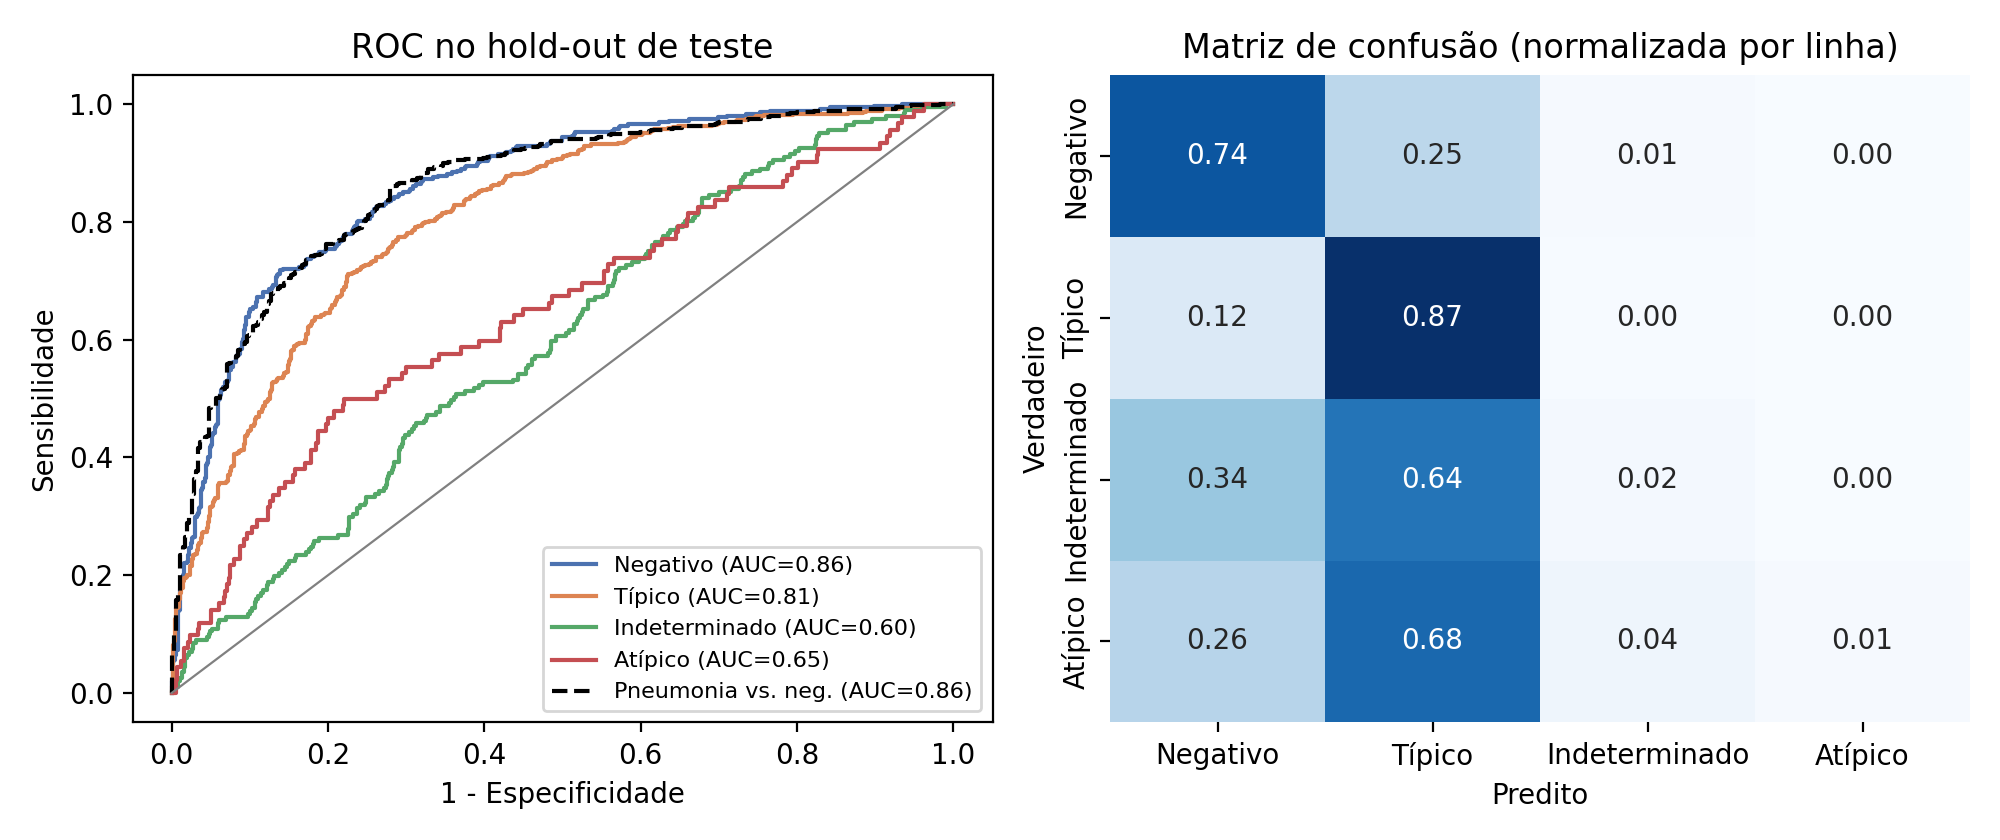

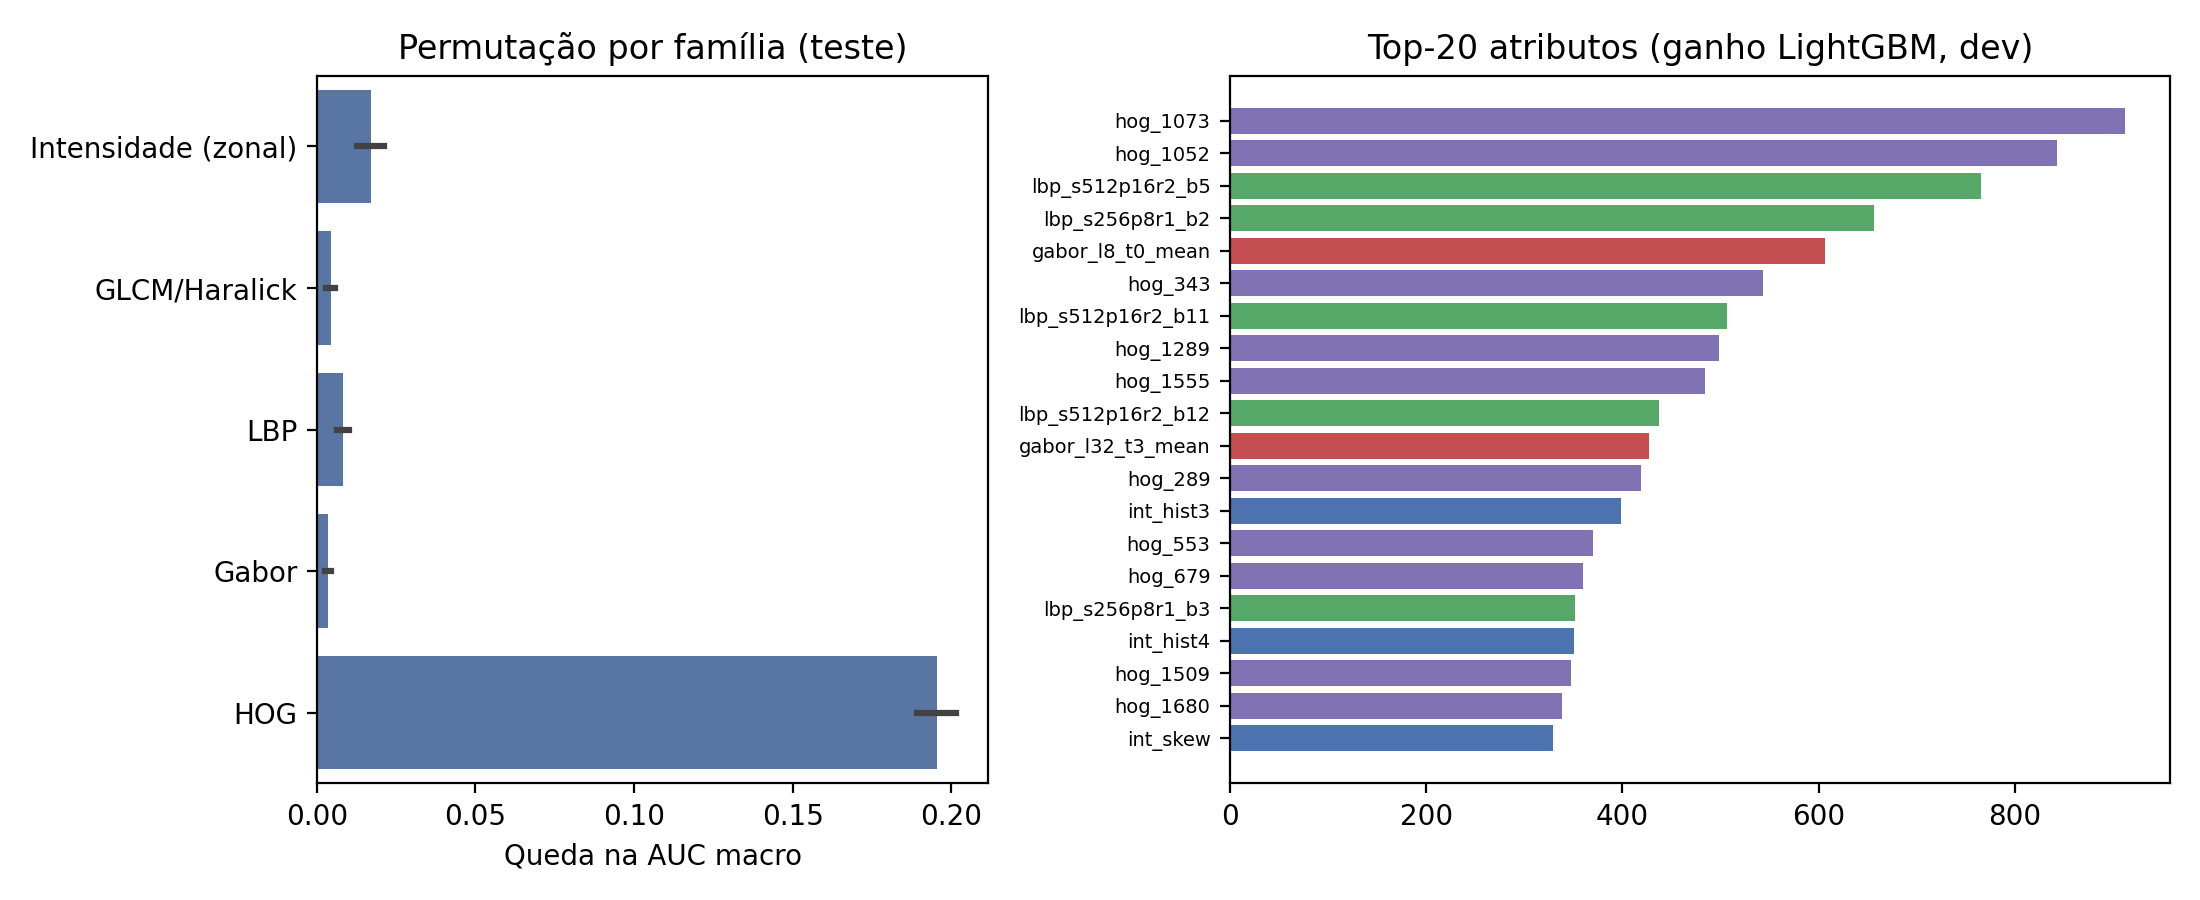

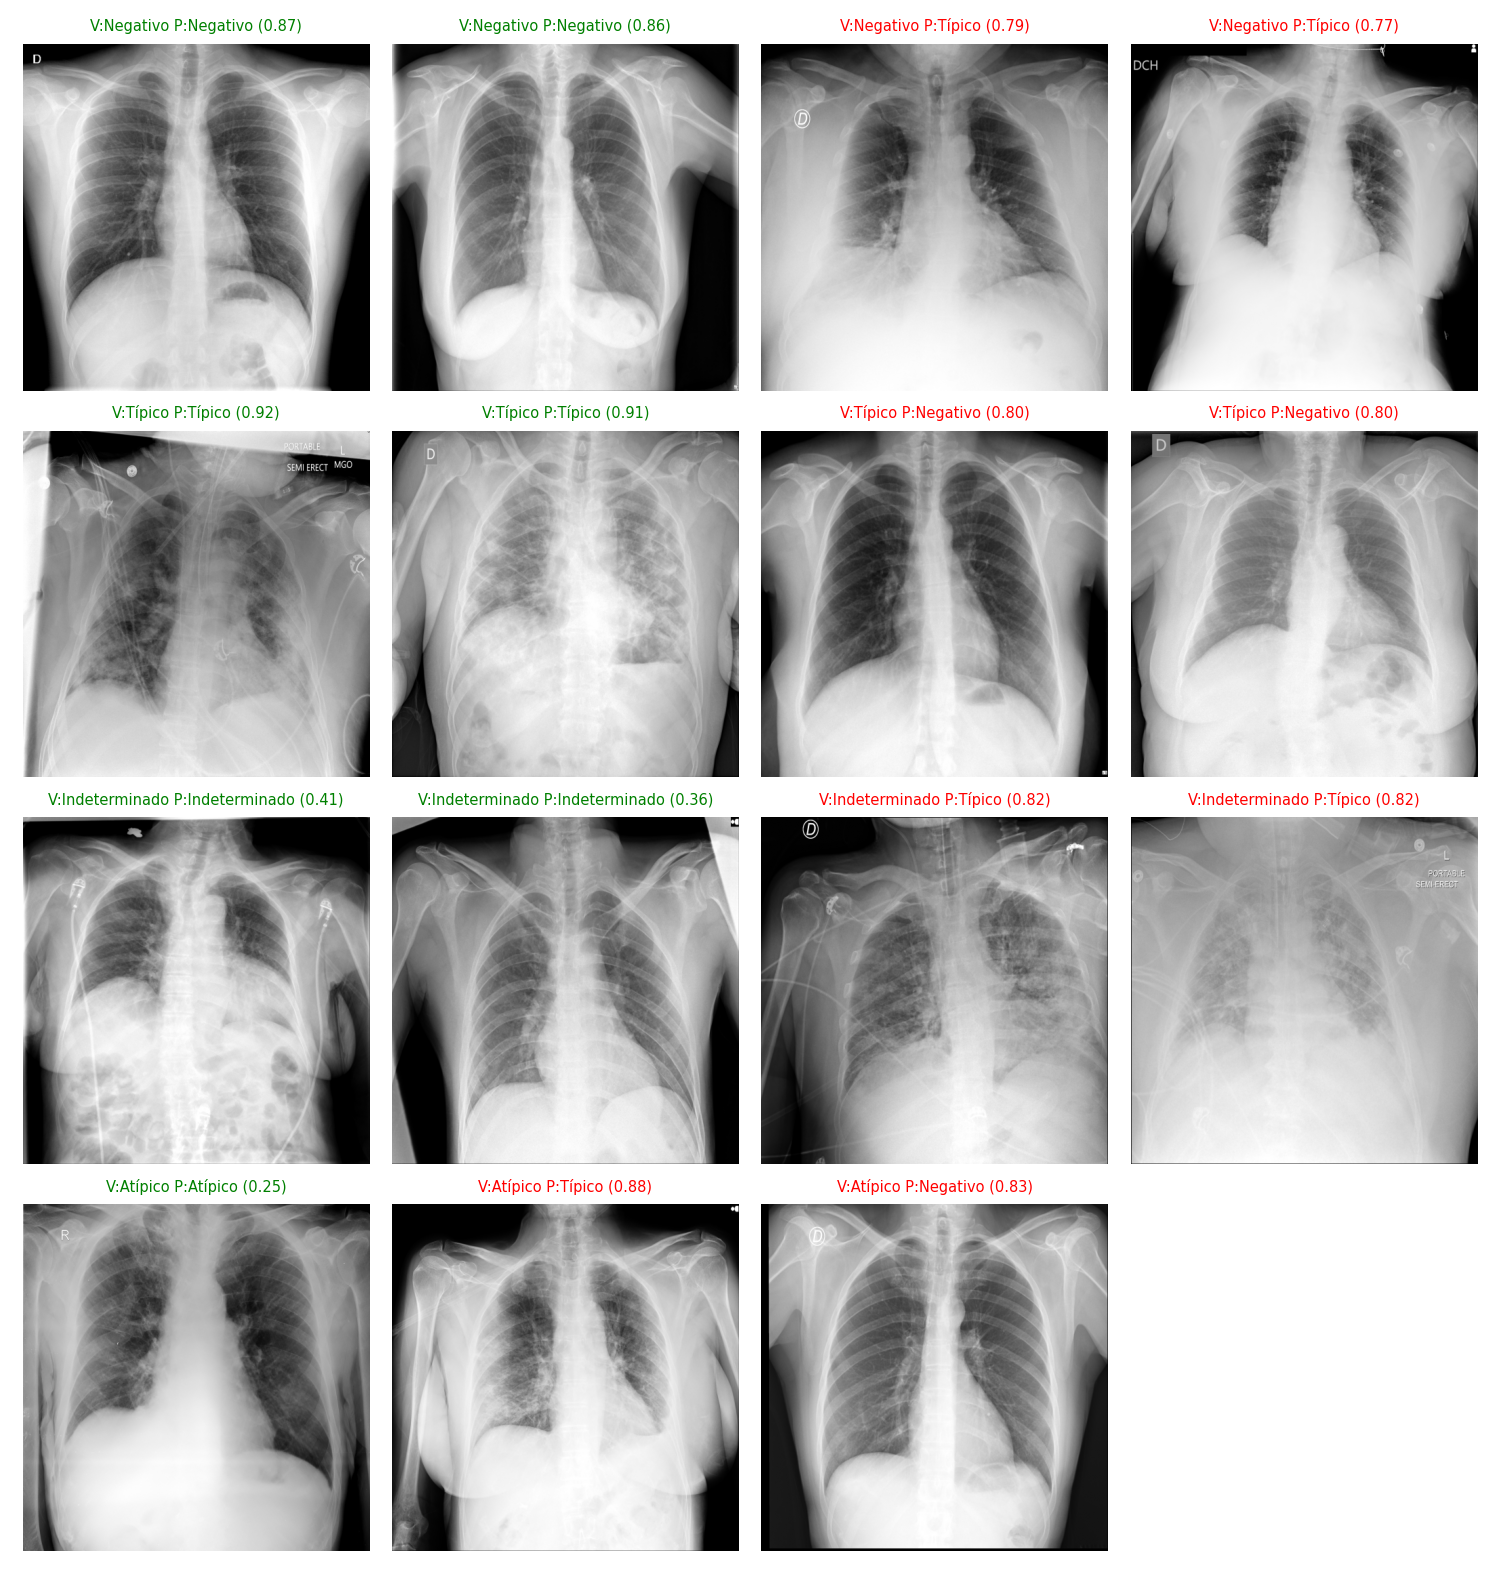

,variavel,valor,n,acuracia,auc_binaria,prev_pneumonia
0,manufacturer,Desconhecido,1274,0.639717,0.861484,0.722135
1,modality,CR,650,0.664615,0.885239,0.732308
2,modality,DX,624,0.613782,0.835160,0.711538
3,mask_fallback,0,1157,0.621435,0.850862,0.696629
4,mask_fallback,1,117,0.820513,0.789474,0.974359


In [8]:
!python src/make_figures.py
for f in ["fig_roc_cm.png", "fig_importance.png", "fig_errors.png"]:
    display(Image(f"{RES}/figures/{f}", width=800))
display(pd.read_csv(f"{RES}/tables/error_by_group.csv"))

## 7. Preencher o artigo com os resultados
Gera `paper/numbers.tex`, copia tabelas e figura para `paper/` e cria `TP1_G4_paper_overleaf.zip` (Overleaf → *New Project* → *Upload Project*).

In [9]:
!python src/fill_paper.py
print(open("paper/numbers.tex").read())

numbers.tex atualizado; projeto LaTeX empacotado em /kaggle/working/repo/results/TP1_G4_paper_overleaf.zip
% Gerado automaticamente por src/fill_paper.py - nao editar a mao.
\newcommand{\AUCImbBal}{0{,}688}
\newcommand{\AUCImbNone}{0{,}699}
\newcommand{\AUCImbSmote}{0{,}681}
\newcommand{\AblClaheDelta}{+0{,}007}
\newcommand{\AblDefaultAUC}{0{,}710}
\newcommand{\AblMaskDelta}{+0{,}014}
\newcommand{\AblRawAUC}{0{,}692}
\newcommand{\AccManufMax}{0{,}640}
\newcommand{\AccManufMin}{0{,}640}
\newcommand{\AccMaskFb}{0{,}821}
\newcommand{\AccMaskOk}{0{,}621}
\newcommand{\AllBestAUC}{0{,}710}
\newcommand{\AtyToTyp}{68{,}5\%}
\newcommand{\BalAccBal}{0{,}426}
\newcommand{\BalAccNone}{0{,}392}
\newcommand{\BalAccSmote}{0{,}416}
\newcommand{\BestConfig}{Todas + SVM-RBF}
\newcommand{\BestFamily}{HOG}
\newcommand{\BestFamilyAUC}{0{,}702}
\newcommand{\BestModelAvg}{SVM-RBF}
\newcommand{\DevAUC}{0{,}710 $\pm$ 0{,}014}
\newcommand{\DevBalAcc}{0{,}395}
\newcommand{\IndToTyp}{64{,}2\%}
\newcommand{\MaskFa

## 8. Empacotar tudo para o GitHub
Baixe `tp1_results.zip` na aba *Output*, descompacte por cima da pasta do repositório e faça commit de `results/`, `splits/` e `paper/`.

In [10]:
!cd /kaggle/working/repo && zip -qr /kaggle/working/tp1_results.zip $RES splits paper
!cp $RES/TP1_G4_paper_overleaf.zip /kaggle/working/ 2>/dev/null; ls -la /kaggle/working

total 16928
drwxr-xr-x  4 root root     4096 Sep 29 22:03 .
drwxr-xr-x  8 root root     4096 Sep 29 19:02 ..
-rw-r--r--  1 root root  4226110 Sep 29 22:03 __notebook__.ipynb
drwxr-xr-x 10 root root     4096 Sep 29 19:04 repo
-rw-r--r--  1 root root  1565619 Sep 29 22:03 TP1_G4_paper_overleaf.zip
-rw-r--r--  1 root root 11519707 Sep 29 22:03 tp1_results.zip
drwxr-xr-x  3 root root     4096 Sep 29 21:45 work
